In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# TM-037-01-investor-sentiment-momentum

Theory **TM-037**. The battery's verdict: the strategy stops at gate 1, hygiene: 8 clustered decisions, fewer than 30.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Market turnover rises with investor sentiment, the propensity to speculate: when optimistic investors trade more, prices run ahead of value, and the market's later returns are lower. High turnover of the market, measured against its own five-year level, is therefore a contrarian sign, and the US stock market earns less over the months after high turnover than over those after low.

**Prediction.** sign: negative (the fund-months after high market turnover earn less over the bill than the fund-months after low market turnover), size: a judgment -- about 1 to 8% a year less, Jones's sign on the market's previous-year turnover (as Acharya and Pedersen report it) and Ilmanen's -0.11 for the Baker-Wurgler composite (its horizon not legible in the library's copy), cut for turnover alone and for SPY's share volume as its proxy; the rule's alpha over the fourteen funds held always about -1 to +2% a year; the base expected to fail gate 1, its decisions likely fewer than thirty (perhaps 5 to 20), gates 3 and 4, and gate 5, whose blocks of 2005-07 and 2008-09 hold the benchmark itself and give no alpha, so that its three positive blocks need all of 2010-14, 2015-19 and 2020-22; possibly gate 2

**What would refute it.** Judged before costs, on the market's closes, over the in-sample fund-months of the base, each from the close of a target's session to the close of the next target's session, the first target on the first session of February 2010, the first on which 1,260 sessions precede it, and the last on the first session of December 2022, whose month ends at the close of 2022-12-30, the last in-sample session, over the funds trading at the target, without the fund-months of the six months of TM-024-01's published panic states inside this window (the months whose targets fall in July, August and September 2010, April and May 2020, and October 2022), left out for all fourteen funds: each fund-month's return less the bill's over the same sessions, regressed by ordinary least squares on an indicator of high turnover at the target (window 252) and one constant for each fund, the standard errors clustered by month, the funds' months in each of the 149 months left one cluster, the t statistic computed apart from the battery. The theory is refuted in this form if the indicator's t statistic is +0.35 or above: the months after high market turnover no worse than the months after low. Between, short of passing gates 1 to 7, not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. Of TM-037's refutation criteria the second is graded, in its market-turnover form and from the contrarian side the library signs; its other proxies, IPOs, closed-end fund discounts, fund flows and issuance, are not held, and its first, anomalies and momentum stronger after high sentiment, reads the composite the lab does not hold and single stocks' short legs, and is not graded. The clause is not graded for CA-029, whose own card would read the illiquidity premium through its own measure; the result is reported to it. The volumes are read as Yahoo reports them; python -m lab.data check lists none of SPY's bars. TM-028-01's published same-session returns on quiet and loud sessions and its variant's contrast on the trend of SPY's quiet sessions, SC-016-01's and SC-027-01's published volume gaps, SC-019-01's returns by year, and TM-047-02's published volatility-managed alpha, its alpha at a beta equal to its average scale and its scale by year are not the graded quantity; their fund-months stay in the graded sample, disclosed. Reported, not graded: the same regression for the variant, window 21; the clause with TM-024-01's six months; the share of months in the high state, and the months in which the state turned; the same regression with SPY's return over the 252 sessions to the session before the target as a control; the same regression with the measure itself as the regressor; the high-turnover months that are months in which TM-047-02's scale, from the five equity funds' 21 sessions of risk, was below one, and the clause without those months; the clause for SPY, QQQ and IWM and for the sector funds; the clause over the months of 2010 to 2016, over those of 2017 to 2022, and over the holdout, 2023 to 2025; the base's alpha before and after costs, and the neighbours' and the one-day-late rule's alphas and appraisal ratios.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: SPY, QQQ, IWM, XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2005-01-04, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

The measure is SPY's log traded volume, as the market's signal volumes give it, averaged over the last window sessions to the session before the target, less its average over the last 1,260 sessions to the session before the target, the five-year detrending fixed; a missing or zero volume is left out of both averages. Turnover is high when the measure is above zero. On the first session of each month, when turnover is high the portfolio is in cash; otherwise each fund trading holds 1/N of the portfolio, N the funds trading. While fewer than 1,260 sessions precede the target the measure is not defined and each fund trading holds 1/N. Everything is read up to the session before; targets are traded at the close.

- **window**: sessions of SPY's log volume whose average is compared with its five-year average, Jones's previous year in the base and Baker and Wurgler's month in the variant

,window
base,252
variant 1,21


Parameter neighbours, moved one at a time for gate 6: window at ±25%: 189, 315; window at ±50%: 126, 378.

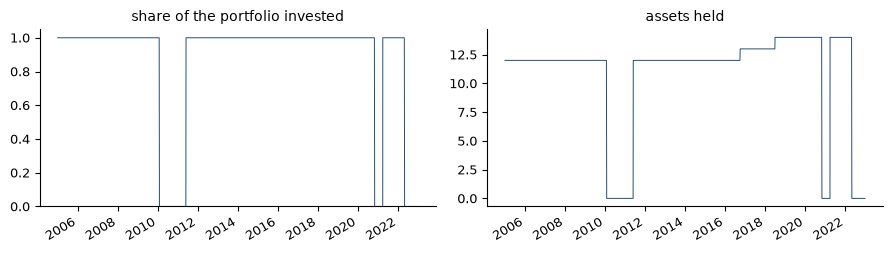

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

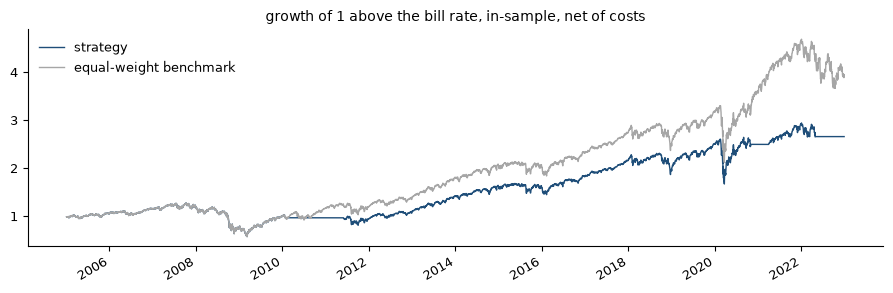

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Fails**: 8 clustered decisions, fewer than 30.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,1260,100,0,none,8,17.98,5


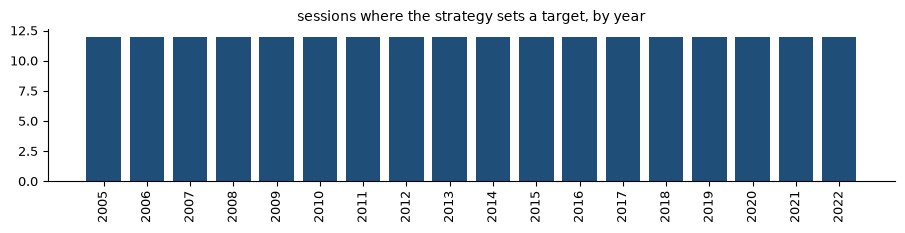

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Fails**: Sharpe 0.392 below 0.4; Sharpe 0.392 against the benchmark's 0.491, alpha -1.21%; at twice the costs, Sharpe 0.391 and alpha -1.22%.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.392,0.4915,-0.01207,0.3906,-0.01221,0.3934,0.000258,0.001427


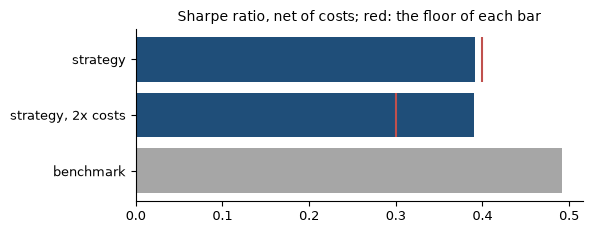

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 14.9% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9696,4531,1000,0.149


Assets that start trading after 2005-01-03: XLC, XLRE. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

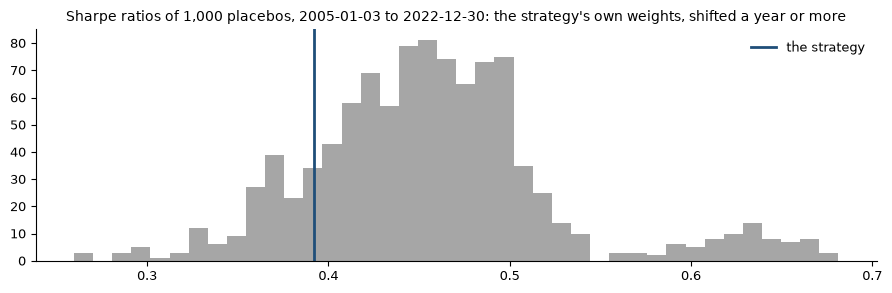

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.000 below 0.9 over 60 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,66,60,-0.1868,0.6124,0.000216


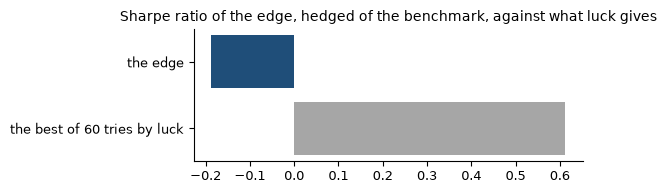

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 2, 3 and 4; alpha positive in 1 of 5 blocks, fewer than 3; alpha -1.37% without its best year, 2009.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,False,False,False,0.3678,1,2009,-0.01372


The blend of the variants: gate 2, Sharpe 0.402 against the benchmark's 0.491, alpha -0.77%; at twice the costs, Sharpe 0.398 and alpha -0.82%; gate 3, beats 19.8% of its shifted placebos, fewer than 90%; gate 4, DSR 0.001 below 0.9 over 60 effective trials.

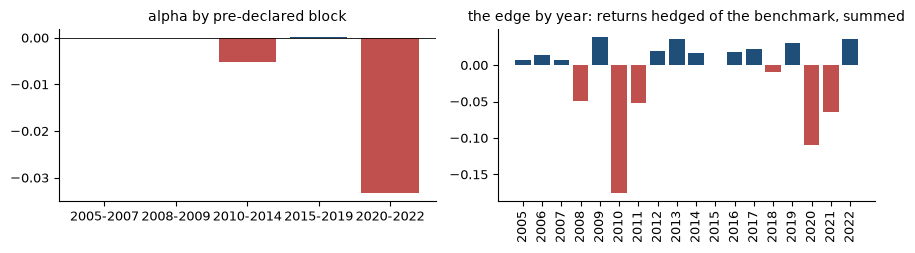

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,1.071,0.877,none,sectors,0.9788,0.1302,XLK,1.028,—,—


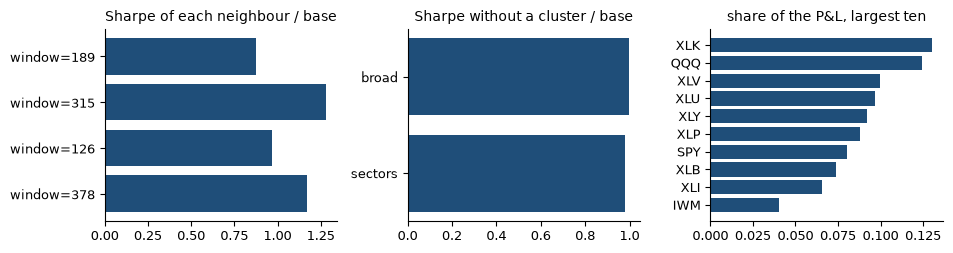

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.48 and alpha -2.66%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.4797,-0.2649,-0.02659,-0.05655,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

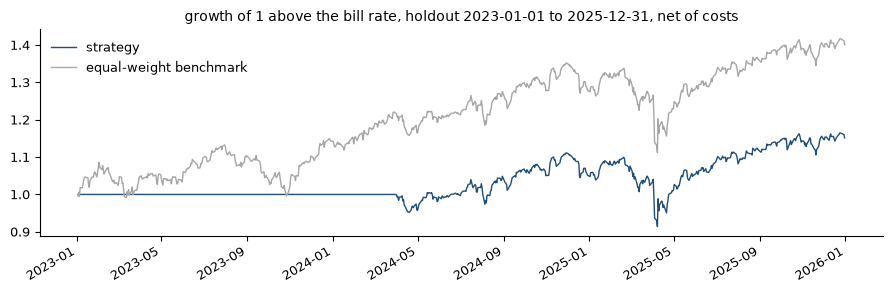

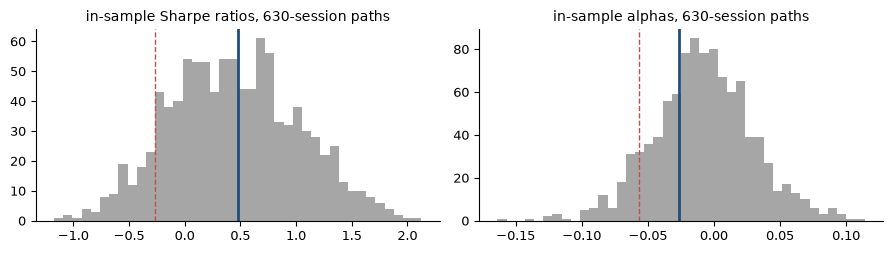

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,fails,"8 clustered decisions, fewer than 30"
2 · Economic edge,fails,"Sharpe 0.392 below 0.4; Sharpe 0.392 against the benchmark's 0.491, alpha -1.21%; at twice the costs, Sharpe 0.391 and alpha -1.22%"
3 · Significance,fails,"beats 14.9% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.000 below 0.9 over 60 effective trials
5 · Stability,fails,"the blend of the variants fails gates 2, 3 and 4; alpha positive in 1 of 5 blocks, fewer than 3; alpha -1.37% without its best year, 2009"
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 0.48 and alpha -2.66%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).